<a href="https://colab.research.google.com/github/NikhilBsc/BscTraining/blob/main/NLP(inclass).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
data ={ "review":["amazing phone","worst battery","excellent camera","bad display","very good performance","poor quality"],"sentiment":["positive","negative","positive","negative","positive","negative"]}
df=pd.DataFrame(data)

df
#

,review,sentiment
0,amazing phone,positive
1,worst battery,negative
2,excellent camera,positive
3,bad display,negative
4,very good performance,positive
5,poor quality,negative


In [2]:
df.shape

(6, 2)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     6 non-null      object
 1   sentiment  6 non-null      object
dtypes: object(2)
memory usage: 228.0+ bytes


In [4]:
df.head()

,review,sentiment
0,amazing phone,positive
1,worst battery,negative
2,excellent camera,positive
3,bad display,negative
4,very good performance,positive


In [5]:
df.tail()

,review,sentiment
1,worst battery,negative
2,excellent camera,positive
3,bad display,negative
4,very good performance,positive
5,poor quality,negative


In [6]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [7]:
df["sentiment"].value_counts()

,count
sentiment,
positive,3
negative,3


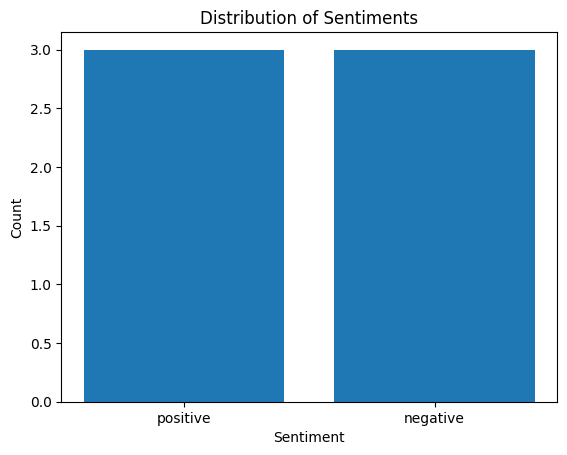

In [10]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [11]:
df["review"]=df["review"].str.lower()
df

,review,sentiment
0,amazing phone,positive
1,worst battery,negative
2,excellent camera,positive
3,bad display,negative
4,very good performance,positive
5,poor quality,negative


In [13]:
df["Length"] = df["review"].apply(len)
df

,review,sentiment,Length
0,amazing phone,positive,13
1,worst battery,negative,13
2,excellent camera,positive,16
3,bad display,negative,11
4,very good performance,positive,21
5,poor quality,negative,12


In [14]:
for review in df["review"]:
  print(review)


amazing phone
worst battery
excellent camera
bad display
very good performance
poor quality


In [17]:
filter =df["review"] == "positive"
filter


,review
0,False
1,False
2,False
3,False
4,False
5,False


In [18]:
sen = input()
print(len(sen))

my name is nik
14


In [ ]:
sen = input()
words = sen.split()
for word in words :
  count =0


#creating sample dataset

In [19]:
df


,review,sentiment,Length
0,amazing phone,positive,13
1,worst battery,negative,13
2,excellent camera,positive,16
3,bad display,negative,11
4,very good performance,positive,21
5,poor quality,negative,12


#remove puncutatuions

In [21]:
import string
sentence ="amzing!!! phone"
table = str.maketrans('','',string.punctuation)
clean = sentence.translate(table)
clean

'amzing phone'

#sentence and word tokenization

In [28]:
data = {
    "Text": [
        "I LOVE this Phone!!! 😍",
        "Worst battery backup!!!",
        "Visit https://abc.com",
        "<h1>Excellent Camera</h1>",
        "Price is 50000 Rupees",
        "Amazing Performance!!!"
    ]
}
df1= pd.DataFrame(data)
df1

,Text
0,I LOVE this Phone!!! 😍
1,Worst battery backup!!!
2,Visit https://abc.com
3,<h1>Excellent Camera</h1>
4,Price is 50000 Rupees
5,Amazing Performance!!!


In [32]:
import nltk
nltk.download('punkt_tab') # Download the specific 'punkt_tab' resource
from nltk.tokenize import sent_tokenize, word_tokenize

text ="i love NLP"
print(sent_tokenize(text))

sentence = "i love learning natural language processing"

print(word_tokenize(sentence))

['i love NLP']
['i', 'love', 'learning', 'natural', 'language', 'processing']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [23]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [34]:
#tokeinizing every review
from nltk.tokenize import word_tokenize
df["tokenized_review"] = df["review"].apply(word_tokenize)
df

,review,sentiment,Length,tokenized_review
0,amazing phone,positive,13,"[amazing, phone]"
1,worst battery,negative,13,"[worst, battery]"
2,excellent camera,positive,16,"[excellent, camera]"
3,bad display,negative,11,"[bad, display]"
4,very good performance,positive,21,"[very, good, performance]"
5,poor quality,negative,12,"[poor, quality]"


#stopwards

In [36]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')

sen = "the phone is very good"
stop_words = set(stopwords.words('english'))
word_tokens = word_tokenize(sen)
filtered_sen = [w for w in word_tokens if not w in stop_words]
filtered_sen

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['phone', 'good']

#stemming

In [37]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

words =["playing","played","studying","running"]
for word in words :
  print(word , '-->',stemmer.stem(word))



playing --> play
played --> play
studying --> studi
running --> run


#lemitiztion


In [40]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

print(lemmatizer.lemmatize('running'))

print(lemmatizer.lemmatize('playing',pos='v'))
print(lemmatizer.lemmatize('studying',pos='v'))

[nltk_data] Downloading package wordnet to /root/nltk_data...


running
play
study


#complete text processing pipelone

In [41]:
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
text = "I LOVE Machine Learning!!! 😃 Visit https://google.com 123"
text = text.lower()
text = re.sub(r'https?://\S+|www\.\S+', '', text)
text = text.translate(str.maketrans('', '', string.punctuation))
text = re.sub(r'\d+', '', text)

text = " ".join(text.split())
tokens = word_tokenize(text)
stop_words = set(stopwords.words('english'))
tokens = [word for word in tokens if word not in stop_words]

print("Final Tokens:")
print(tokens)



Final Tokens:
['love', 'machine', 'learning', '😃', 'visit']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [44]:
import pandas as pd
from nltk.tokenize import word_tokenize
import nltk
nltk.download('averaged_perceptron_tagger_eng')
from nltk import pos_tag
data = {"sentence":["i love nlp","python is amazing","students are learning AI"]}
df = pd.DataFrame(data)
df["Tokens"] = df["sentence"].apply(word_tokenize)
df["pos_tags"] = df["Tokens"].apply(pos_tag)
df


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


,sentence,Tokens,pos_tags
0,i love nlp,"[i, love, nlp]","[(i, NN), (love, VBP), (nlp, NN)]"
1,python is amazing,"[python, is, amazing]","[(python, NN), (is, VBZ), (amazing, VBG)]"
2,students are learning AI,"[students, are, learning, AI]","[(students, NNS), (are, VBP), (learning, VBG),..."


#chunking using nltk
(Also called shallow parsing)

In [45]:
from nltk.chunk import RegexpParser
sentence="the intelligent student won the competition"
tokens=word_tokenize(sentence)
tags=pos_tag(tokens)
grammer="NP: {<DT>?<JJ>*<NN>}"
cp=RegexpParser(grammer)
result=cp.parse(tags)
print(result)

(S
  (NP the/DT intelligent/JJ student/NN)
  won/VBD
  (NP the/DT competition/NN))


In [47]:
#dependency parsing usingspacy

import spacy
from spacy import displacy
nip = spacy.load("en_core_web_sm")
sentence = "john eats piza"
doc = nip(sentence)
for token in doc:
  print(token.text , token.dep_,token.head.text)

displacy.render(doc , style ="dep",jupyter = True)

john nsubj eats
eats ROOT eats
piza dobj eats


#Named Entity Recognition(NER)using Spacy

In [49]:
import spacy
from spacy import displacy
nlp = spacy.load("en_core_web_sm")
doc =nlp("Elon Musk is the CEO of Tesla and lives in Texas.")

for entity in doc.ents:
  print(entity.text , entity.label_)

displacy.render(doc , style ="ent", jupyter = True)

Elon Musk PERSON
Tesla ORG
Texas GPE


#word senses & synonymns with wordnet

In [52]:
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet')


car_synsets = wordnet.synsets("car")

print("Synsets of 'car':")
print(car_synsets)

Synsets of 'car':
[Synset('car.n.01'), Synset('car.n.02'), Synset('car.n.03'), Synset('car.n.04'), Synset('cable_car.n.01')]


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#mini project(linguistic pipeline)

In [54]:
import pandas as pd
import spacy

nlp = spacy.load("en_core_web_sm")
data={"sentence":["elon musk founded spacex in californa","apple released the new iphone","rahul is studying artificial inteeligence and machine laeraning"]}
df=pd.DataFrame(data)
df

,sentence
0,elon musk founded spacex in californa
1,apple released the new iphone
2,rahul is studying artificial inteeligence and ...


In [55]:
for sentence in df['sentence']:
  doc = nlp(sentence)
  tokens = [t.text for t in doc]
  pos = [(t.text,t.pos) for t in doc]

  ents = [(e.text,e.label_) for e in doc.ents ]

print(tokens)
print(pos)
print(ents)

['rahul', 'is', 'studying', 'artificial', 'inteeligence', 'and', 'machine', 'laeraning']
[('rahul', <univ_pos_t.NOUN: 92>), ('is', <univ_pos_t.AUX: 87>), ('studying', <univ_pos_t.VERB: 100>), ('artificial', <univ_pos_t.ADJ: 84>), ('inteeligence', <univ_pos_t.NOUN: 92>), ('and', <univ_pos_t.CCONJ: 89>), ('machine', <univ_pos_t.NOUN: 92>), ('laeraning', <univ_pos_t.NOUN: 92>)]
[]


In [ ]:
#29
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)
cm = confusion_matrix(
    y_true,
    y_pred_classes
)
print("Confusion Matrix")
print(cm)
print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred_classes
    )
)